# 32. Regime-Aware Cross-Sectional Alpha Trading System

## Objective
Build a production-style, leakage-safe, regime-aware alpha allocation and trend-forecast mapping system on top of Step-28 and Step-31 outputs.

**Core principles enforced:**
- preserve Step-28 ranking integrity
- no prediction smoothing
- no synthetic targets
- no leakage (all routing and regime controls use information available at time t only)
- no trades in statistically negative-alpha regimes

In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Dict, List, Tuple
import logging

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import spearmanr
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x)

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 320)
pd.set_option('display.width', 260)

TRAIN_START = pd.Timestamp('2023-01-01')
TRAIN_END = pd.Timestamp('2024-12-31')
TEST_START = pd.Timestamp('2025-01-01')
TEST_END = pd.Timestamp('2025-12-31')

TX_COST = 0.0015
SLIPPAGE = 0.0010
TOP_N = 10
MIDDLE_DROP = 0.60
ANNUALIZATION_DAYS = 252
RANDOM_BENCHMARK_SIMS = 30
RANDOM_STATE = 42

logger = logging.getLogger('step32_regime_aware_alpha')
if not logger.handlers:
    h = logging.StreamHandler()
    h.setFormatter(logging.Formatter('[%(levelname)s] %(message)s'))
    logger.addHandler(h)
logger.setLevel(logging.INFO)


In [2]:
def resolve_project_root() -> Path:
    cwd = Path.cwd()
    for c in [cwd, cwd.parent, cwd.parent.parent]:
        if (c / 'ml_pipeline').exists() and (c / 'CLAUDE.md').exists():
            return c
    raise FileNotFoundError('Unable to locate project root.')


def cs_zscore(s: pd.Series) -> pd.Series:
    sd = s.std(ddof=0)
    if pd.isna(sd) or sd == 0:
        return pd.Series(0.0, index=s.index)
    return (s - s.mean()) / sd


def sharpe_ratio(daily_returns: pd.Series, annualization: int = ANNUALIZATION_DAYS) -> float:
    mu = float(daily_returns.mean())
    sigma = float(daily_returns.std(ddof=1))
    if sigma == 0.0 or np.isnan(sigma):
        return np.nan
    return (mu / sigma) * np.sqrt(annualization)


def sortino_ratio(daily_returns: pd.Series, annualization: int = ANNUALIZATION_DAYS) -> float:
    downside = daily_returns[daily_returns < 0]
    dstd = float(downside.std(ddof=1))
    if dstd == 0.0 or np.isnan(dstd):
        return np.nan
    return float(daily_returns.mean()) / dstd * np.sqrt(annualization)


def max_drawdown(equity: pd.Series) -> float:
    running_max = equity.cummax()
    dd = equity / running_max - 1.0
    return float(dd.min()) if len(dd) else np.nan


def safe_roc_auc(y_true: pd.Series, y_prob: pd.Series) -> float:
    y = y_true.astype(int)
    if y.nunique() < 2:
        return np.nan
    return float(roc_auc_score(y, y_prob))


def daily_ic(df_in: pd.DataFrame, pred_col: str, target_col: str = 'target_future_return_t3') -> pd.DataFrame:
    rows = []
    for dt, g in df_in.groupby('Date', sort=True):
        g = g[[pred_col, target_col]].dropna()
        if len(g) < 10:
            continue
        corr, _ = spearmanr(g[pred_col], g[target_col])
        if pd.notna(corr):
            rows.append({'Date': dt, 'IC': float(corr)})
    out = pd.DataFrame(rows)
    if len(out):
        out['IC_rolling_20'] = out['IC'].rolling(20, min_periods=5).mean()
        out['IC_rolling_60'] = out['IC'].rolling(60, min_periods=20).mean()
    return out


def compute_metrics(daily_ret: pd.Series) -> Dict[str, float]:
    daily = daily_ret.sort_index()
    if len(daily) == 0:
        return {
            'Total return': np.nan,
            'CAGR': np.nan,
            'Sharpe': np.nan,
            'Sortino': np.nan,
            'Max drawdown': np.nan,
            'Volatility': np.nan,
            'Calmar': np.nan,
            'Win rate': np.nan,
        }
    eq = (1.0 + daily).cumprod()
    years = max((daily.index.max() - daily.index.min()).days / 365.25, 1e-9)
    total_ret = float(eq.iloc[-1] - 1.0)
    cagr = float(eq.iloc[-1] ** (1.0 / years) - 1.0) if years > 0 else np.nan
    vol = float(daily.std(ddof=1) * np.sqrt(ANNUALIZATION_DAYS))
    mdd = float(max_drawdown(eq))
    calmar = float(cagr / abs(mdd)) if pd.notna(mdd) and mdd < 0 else np.nan
    return {
        'Total return': total_ret,
        'CAGR': cagr,
        'Sharpe': sharpe_ratio(daily),
        'Sortino': sortino_ratio(daily),
        'Max drawdown': mdd,
        'Volatility': vol,
        'Calmar': calmar,
        'Win rate': float((daily > 0).mean()),
    }


ROOT = resolve_project_root()
BASE = ROOT / 'ml_pipeline'
STEP28_PATH = BASE / 'Market_Data' / 'final' / 'cross_sectional_alpha_results.parquet'
STEP31_PATH = BASE / 'Market_Data' / 'final' / 'step31_recovered_alpha.parquet'
STEP30_PATH = BASE / 'Market_Data' / 'final' / 'ensemble_alpha_results.parquet'
STEP24_PATH = BASE / 'Market_Data' / 'final' / 'final_strategy_results.parquet'
FINAL_MODEL_PATH = BASE / 'Market_Data' / 'processed' / 'final_model_dataset.parquet'

OUT_STRATEGY = BASE / 'Market_Data' / 'final' / 'step32_regime_aware_alpha_strategy.parquet'
OUT_TREND = BASE / 'Market_Data' / 'final' / 'final_trend_forecasts.parquet'
OUT_METRICS = BASE / 'Market_Data' / 'final' / 'step32_metrics_summary.csv'

assert STEP28_PATH.exists(), f'Missing Step-28 file: {STEP28_PATH}'
assert STEP31_PATH.exists(), f'Missing Step-31 file: {STEP31_PATH}'
assert FINAL_MODEL_PATH.exists(), f'Missing final_model_dataset.parquet: {FINAL_MODEL_PATH}'
assert STEP24_PATH.exists(), f'Missing Step-24 benchmark file: {STEP24_PATH}'

step28 = pd.read_parquet(STEP28_PATH).copy()
step31 = pd.read_parquet(STEP31_PATH).copy()
base_df = pd.read_parquet(FINAL_MODEL_PATH).copy()
step24 = pd.read_parquet(STEP24_PATH).copy()
step30 = pd.read_parquet(STEP30_PATH).copy() if STEP30_PATH.exists() else pd.DataFrame()

for d in [step28, step31, base_df, step24, step30]:
    if 'Date' in d.columns:
        d['Date'] = pd.to_datetime(d['Date'])

step28 = step28[(step28['Date'] >= TEST_START) & (step28['Date'] <= TEST_END)].copy()
step31 = step31[(step31['Date'] >= TEST_START) & (step31['Date'] <= TEST_END)].copy()
base_df = base_df.sort_values(['Ticker', 'Date']).copy()

g_close = base_df.groupby('Ticker', sort=False)['Close']
base_df['target_future_return_t3'] = g_close.shift(-3) / base_df['Close'] - 1.0

# Regime source: use label if available, otherwise infer from train-period Volatility_20 terciles.
if 'volatility_regime_label' in base_df.columns:
    base_df['Regime'] = base_df['volatility_regime_label'].astype(str).str.upper().replace({'STABLE': 'MEDIUM', 'NON-VOLATILE': 'LOW', 'NON_VOLATILE': 'LOW'})
else:
    train_vol = base_df[(base_df['Date'] >= TRAIN_START) & (base_df['Date'] <= TRAIN_END)]['Volatility_20']
    q1 = float(train_vol.quantile(1 / 3))
    q2 = float(train_vol.quantile(2 / 3))
    base_df['Regime'] = np.where(base_df['Volatility_20'] <= q1, 'LOW', np.where(base_df['Volatility_20'] <= q2, 'MEDIUM', 'HIGH'))

regime_map = base_df[['Date', 'Ticker', 'Regime', 'target_future_return_t3']].copy()

# STEP 1 load + align
w = step28[['Date', 'Ticker', 'target_future_return_t3', 'pred_LightGBMRegressor', 'pred_XGBoostRegressor']].copy()
w = w.merge(step31[['Date', 'Ticker', 'pred_final', 'rank', 'zscore', 'ic_mean_step31', 'sharpe_step31']] if {'pred_final', 'rank', 'zscore'}.issubset(step31.columns) else step31[['Date','Ticker']], on=['Date', 'Ticker'], how='left')
w = w.merge(regime_map, on=['Date', 'Ticker'], how='left', suffixes=('', '_base'))
w['target_future_return_t3'] = w['target_future_return_t3'].fillna(w['target_future_return_t3_base'])
w = w.drop(columns=[c for c in w.columns if c.endswith('_base')])

w = w.drop_duplicates(subset=['Date', 'Ticker']).sort_values(['Date', 'Ticker']).reset_index(drop=True)
assert not w[['Date', 'Ticker']].duplicated().any(), 'Duplicates found after alignment.'
assert w['Date'].is_monotonic_increasing, 'Date ordering is not chronological.'

logger.info('Aligned shape: %s x %s', f'{w.shape[0]:,}', f'{w.shape[1]:,}')
print(f"Date range: {w['Date'].min().date()} -> {w['Date'].max().date()}")
print('Regime counts:')
display(w['Regime'].value_counts(dropna=False).rename('count').to_frame())
display(w.head(8))


[INFO] Aligned shape: 4,900 x 11


Date range: 2025-01-01 -> 2025-12-24
Regime counts:


,count
Regime,
HIGH,2081
MEDIUM,1478
LOW,1341


,Date,Ticker,target_future_return_t3,pred_LightGBMRegressor,pred_XGBoostRegressor,pred_final,rank,zscore,ic_mean_step31,sharpe_step31,Regime
0,2025-01-01,ADANIENT,-0.031470,0.023142,0.025071,0.95,0.95,1.474087,0.026841,2.627988,HIGH
1,2025-01-01,ADANIPORTS,-0.045663,0.009093,0.023497,0.60,0.60,0.260133,0.026841,2.627988,MEDIUM
2,2025-01-01,ADANIPOWER,-0.053831,0.009626,0.023923,0.80,0.80,0.953821,0.026841,2.627988,HIGH
3,2025-01-01,AMBUJACEM,-0.016153,-0.005614,0.018494,0.30,0.30,-0.780399,0.026841,2.627988,LOW
4,2025-01-01,BAJAJHLDNG,-0.068998,0.036119,0.042087,1.00,1.00,1.647509,0.026841,2.627988,HIGH
5,2025-01-01,BEL,-0.039980,-0.004693,0.016567,0.45,0.45,-0.260133,0.026841,2.627988,MEDIUM
6,2025-01-01,CHOLAFIN,0.092751,0.009370,0.017999,0.75,0.75,0.780399,0.026841,2.627988,HIGH
7,2025-01-01,DRREDDY,-0.013623,-0.008015,0.015527,0.15,0.15,-1.300665,0.026841,2.627988,MEDIUM


In [3]:
# STEP 2 regime diagnostics
w['pred_anchor'] = w['pred_LightGBMRegressor']

step28_ic = float(step28['ic_mean_selected'].iloc[0]) if 'ic_mean_selected' in step28.columns else np.nan
step31_ic = float(step31['ic_mean_step31'].dropna().iloc[0]) if 'ic_mean_step31' in step31.columns and step31['ic_mean_step31'].notna().any() else np.nan
use_step31_signal = bool(pd.notna(step31_ic) and pd.notna(step28_ic) and step31_ic > step28_ic and 'pred_final' in w.columns)

if use_step31_signal:
    w['signal_raw'] = w['pred_final']
    selected_signal = 'Step-31 pred_final'
else:
    w['signal_raw'] = w['pred_anchor']
    selected_signal = 'Step-28 LightGBM anchor'

w['pred_rank_pct'] = w.groupby('Date')['signal_raw'].rank(pct=True)
w['pred_zscore'] = w.groupby('Date')['signal_raw'].transform(cs_zscore)
w['signal_strength'] = (w['pred_rank_pct'] - 0.5).abs()

regime_rows = []
for reg in ['LOW', 'MEDIUM', 'HIGH']:
    sub = w[w['Regime'] == reg].copy()
    ic_sub = daily_ic(sub, 'signal_raw', 'target_future_return_t3')
    regime_rows.append({
        'Regime': reg,
        'Mean_IC': float(ic_sub['IC'].mean()) if len(ic_sub) else np.nan,
        'IC_Std': float(ic_sub['IC'].std(ddof=1)) if len(ic_sub) > 1 else np.nan,
        'IC_Hit_Rate': float((ic_sub['IC'] > 0).mean()) if len(ic_sub) else np.nan,
        'Mean_future_return': float(sub['target_future_return_t3'].mean()) if len(sub) else np.nan,
        'Signal_spread_mean': float(sub['signal_strength'].mean()) if len(sub) else np.nan,
        'Signal_spread_std': float(sub['signal_strength'].std(ddof=1)) if len(sub) > 1 else np.nan,
        'Rows': int(len(sub)),
    })
regime_diag = pd.DataFrame(regime_rows)
display(regime_diag.round(4))
print(f'Signal source selected: {selected_signal}')

# Daily IC and historical IC features for routing (shifted -> leakage-safe).
ic_daily_all = daily_ic(w, 'signal_raw', 'target_future_return_t3').sort_values('Date').reset_index(drop=True)
ic_daily_all['IC_rolling_20_hist'] = ic_daily_all['IC'].rolling(20, min_periods=5).mean().shift(1)
w = w.merge(ic_daily_all[['Date', 'IC', 'IC_rolling_20_hist', 'IC_rolling_20', 'IC_rolling_60']], on='Date', how='left')

# STEP 3 regime filter engine
daily_signal_median_hist = (
    w.groupby('Date', as_index=True)['signal_strength']
    .median()
    .rolling(20, min_periods=5)
    .median()
    .shift(1)
)
w['signal_median_hist'] = w['Date'].map(daily_signal_median_hist)

w['trade_allowed'] = False
w.loc[w['Regime'] == 'MEDIUM', 'trade_allowed'] = True
high_cond = (w['Regime'] == 'HIGH') & ((w['signal_strength'] > w['signal_median_hist']) | (w['IC_rolling_20_hist'] > 0))
w.loc[high_cond, 'trade_allowed'] = True
w.loc[w['Regime'] == 'LOW', 'trade_allowed'] = False

display(w[['Date', 'Ticker', 'Regime', 'signal_strength', 'signal_median_hist', 'IC_rolling_20_hist', 'trade_allowed']].head(12))

# STEP 4 regime-based adaptive capital allocation
base_alloc = {'LOW': 0.0, 'MEDIUM': 0.70, 'HIGH': 0.30}
pos_ic = regime_diag.set_index('Regime')['Mean_IC'].clip(lower=0).to_dict()
sum_pos = sum(pos_ic.get(r, 0.0) for r in ['MEDIUM', 'HIGH'])
if sum_pos > 0:
    adaptive_alloc = {
        'LOW': 0.0,
        'MEDIUM': pos_ic.get('MEDIUM', 0.0) / sum_pos,
        'HIGH': pos_ic.get('HIGH', 0.0) / sum_pos,
    }
else:
    adaptive_alloc = {'LOW': 0.0, 'MEDIUM': 0.70, 'HIGH': 0.30}

# Blend baseline and adaptive to stabilize allocations.
final_alloc = {
    'LOW': 0.0,
    'MEDIUM': 0.5 * base_alloc['MEDIUM'] + 0.5 * adaptive_alloc['MEDIUM'],
    'HIGH': 0.5 * base_alloc['HIGH'] + 0.5 * adaptive_alloc['HIGH'],
}
norm = final_alloc['MEDIUM'] + final_alloc['HIGH']
if norm > 0:
    final_alloc['MEDIUM'] /= norm
    final_alloc['HIGH'] /= norm

alloc_diag = pd.DataFrame([
    {'Regime': 'LOW', 'BaseWeight': base_alloc['LOW'], 'AdaptiveWeight': adaptive_alloc['LOW'], 'FinalWeight': final_alloc['LOW']},
    {'Regime': 'MEDIUM', 'BaseWeight': base_alloc['MEDIUM'], 'AdaptiveWeight': adaptive_alloc['MEDIUM'], 'FinalWeight': final_alloc['MEDIUM']},
    {'Regime': 'HIGH', 'BaseWeight': base_alloc['HIGH'], 'AdaptiveWeight': adaptive_alloc['HIGH'], 'FinalWeight': final_alloc['HIGH']},
])
display(alloc_diag.round(4))


,Regime,Mean_IC,IC_Std,IC_Hit_Rate,Mean_future_return,Signal_spread_mean,Signal_spread_std,Rows
0,LOW,-0.0680,0.3926,0.3673,-0.0007,0.2263,0.1412,1341
1,MEDIUM,0.0391,0.3396,0.5200,0.0018,0.2304,0.1397,1478
2,HIGH,0.0698,0.3148,0.5743,0.0044,0.2792,0.1479,2081


Signal source selected: Step-31 pred_final


,Date,Ticker,Regime,signal_strength,signal_median_hist,IC_rolling_20_hist,trade_allowed
0,2025-01-01,ADANIENT,HIGH,0.45,NaN,NaN,False
1,2025-01-01,ADANIPORTS,MEDIUM,0.10,NaN,NaN,True
2,2025-01-01,ADANIPOWER,HIGH,0.30,NaN,NaN,False
3,2025-01-01,AMBUJACEM,LOW,0.20,NaN,NaN,False
4,2025-01-01,BAJAJHLDNG,HIGH,0.50,NaN,NaN,False
5,2025-01-01,BEL,MEDIUM,0.05,NaN,NaN,True
6,2025-01-01,CHOLAFIN,HIGH,0.25,NaN,NaN,False
7,2025-01-01,DRREDDY,MEDIUM,0.35,NaN,NaN,True
8,2025-01-01,GODREJCP,HIGH,0.15,NaN,NaN,False
9,2025-01-01,HDFCLIFE,LOW,0.00,NaN,NaN,False


,Regime,BaseWeight,AdaptiveWeight,FinalWeight
0,LOW,0.0,0.0000,0.0000
1,MEDIUM,0.7,0.3591,0.5296
2,HIGH,0.3,0.6409,0.4704


,Total return,CAGR,Sharpe,Sortino,Max drawdown,Volatility,Calmar,Win rate
0,-0.3771,-0.3839,-2.1312,-3.1724,-0.412,0.2172,-0.9317,0.4327


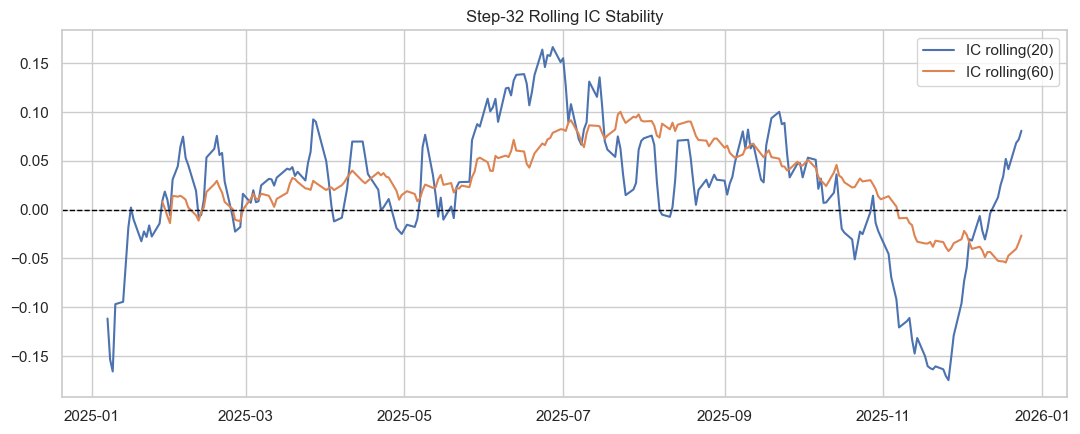

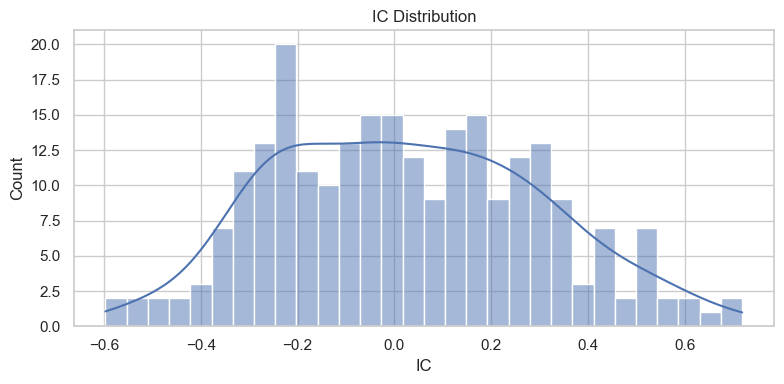

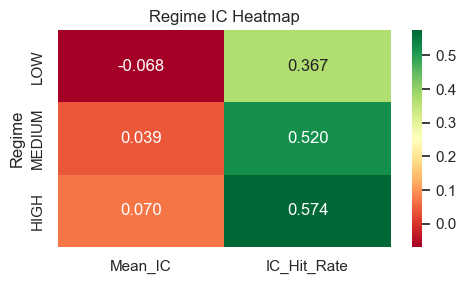

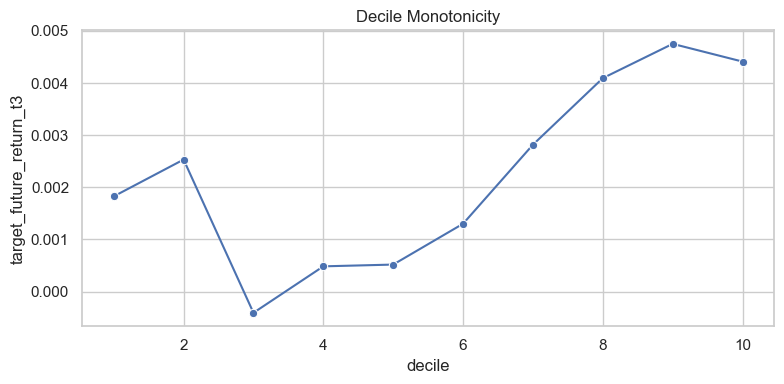

In [4]:
# STEP 6 trade filtering (remove middle 60%, keep top/bottom 20%)
w['top_cut'] = w.groupby('Date')['pred_rank_pct'].transform(lambda x: x.quantile(1 - (1 - MIDDLE_DROP) / 2))
w['bot_cut'] = w.groupby('Date')['pred_rank_pct'].transform(lambda x: x.quantile((1 - MIDDLE_DROP) / 2))
w['tail_selected'] = (w['pred_rank_pct'] >= w['top_cut']) | (w['pred_rank_pct'] <= w['bot_cut'])
w['trade_candidate'] = w['trade_allowed'] & w['tail_selected']
w['side'] = np.where(w['pred_rank_pct'] >= 0.5, 1, -1)

# STEP 7 portfolio construction (signal-strength weighted + regime allocation multiplier)
port_rows: List[pd.DataFrame] = []
for dt, g in w.groupby('Date', sort=True):
    c = g[g['trade_candidate']].copy()
    if len(c) < 2:
        g2 = g.copy()
        g2['weight_pre'] = 0.0
        port_rows.append(g2)
        continue

    longs = c[c['side'] == 1].sort_values('pred_rank_pct', ascending=False).head(TOP_N).copy()
    shorts = c[c['side'] == -1].sort_values('pred_rank_pct', ascending=True).head(TOP_N).copy()
    picks = pd.concat([longs, shorts], ignore_index=True)

    if len(picks) == 0:
        g2 = g.copy()
        g2['weight_pre'] = 0.0
        port_rows.append(g2)
        continue

    picks['regime_multiplier'] = picks['Regime'].map(final_alloc).fillna(0.0)
    picks['raw_abs'] = picks['signal_strength'].clip(lower=1e-6) * picks['regime_multiplier']

    long_sum = picks.loc[picks['side'] == 1, 'raw_abs'].sum()
    short_sum = picks.loc[picks['side'] == -1, 'raw_abs'].sum()
    picks['weight_pre'] = 0.0
    if long_sum > 0:
        picks.loc[picks['side'] == 1, 'weight_pre'] = 0.5 * picks.loc[picks['side'] == 1, 'raw_abs'] / long_sum
    if short_sum > 0:
        picks.loc[picks['side'] == -1, 'weight_pre'] = -0.5 * picks.loc[picks['side'] == -1, 'raw_abs'] / short_sum

    g2 = g.copy()
    g2 = g2.merge(picks[['Ticker', 'weight_pre']], on='Ticker', how='left')
    g2['weight_pre'] = g2['weight_pre'].fillna(0.0)
    port_rows.append(g2)

port = pd.concat(port_rows, ignore_index=True).sort_values(['Ticker', 'Date']).reset_index(drop=True)
daily_abs_weight = port.groupby('Date')['weight_pre'].transform(lambda x: np.abs(x).sum()).fillna(0.0)
port['weight_pre'] = np.where(daily_abs_weight > 0, port['weight_pre'] / daily_abs_weight, 0.0)
daily_abs_weight_check = port.groupby('Date')['weight_pre'].apply(lambda x: np.abs(x).sum()).fillna(0.0).to_numpy()
assert np.all((np.isclose(daily_abs_weight_check, 1.0, atol=1e-4, rtol=0.0)) | (daily_abs_weight_check == 0.0)), 'Daily gross exposure must be 1.0 (or 0.0 when no trades).'

# STEP 8 realistic execution model
port['prev_weight'] = port.groupby('Ticker', sort=False)['weight_pre'].shift(1).fillna(0.0)
port['turnover_component'] = (port['weight_pre'] - port['prev_weight']).abs()
port['gross_component'] = port['weight_pre'] * port['target_future_return_t3']
port['cost_component'] = (TX_COST + SLIPPAGE) * port['turnover_component']
port['net_component'] = port['gross_component'] - port['cost_component']

daily = port.groupby('Date', as_index=True).agg(
    gross_return=('gross_component', 'sum'),
    cost=('cost_component', 'sum'),
    net_return=('net_component', 'sum'),
    turnover=('turnover_component', 'sum'),
).sort_index()
daily['equity'] = (1.0 + daily['net_return']).cumprod()
daily['rolling_sharpe_20'] = daily['net_return'].rolling(20, min_periods=10).apply(lambda x: sharpe_ratio(pd.Series(x)), raw=False)

# STEP 9 backtest metrics
m32 = compute_metrics(daily['net_return'])
display(pd.DataFrame([m32]).round(4))

# STEP 10 IC stability analysis
ic_day = daily_ic(port, 'signal_raw', 'target_future_return_t3').sort_values('Date')

plt.figure(figsize=(11, 4.5))
if len(ic_day):
    plt.plot(ic_day['Date'], ic_day['IC_rolling_20'], label='IC rolling(20)')
    plt.plot(ic_day['Date'], ic_day['IC_rolling_60'], label='IC rolling(60)')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Step-32 Rolling IC Stability')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(ic_day['IC'].dropna(), bins=30, kde=True)
plt.title('IC Distribution')
plt.tight_layout()
plt.show()

regime_heat = regime_diag[['Regime', 'Mean_IC', 'IC_Hit_Rate']].set_index('Regime')
plt.figure(figsize=(5, 3))
sns.heatmap(regime_heat, annot=True, fmt='.3f', cmap='RdYlGn')
plt.title('Regime IC Heatmap')
plt.tight_layout()
plt.show()

# STEP 11 decile monotonicity
mono = port[['Date', 'Ticker', 'signal_raw', 'target_future_return_t3']].copy()
mono['decile'] = mono.groupby('Date')['signal_raw'].transform(lambda x: pd.qcut(x.rank(method='first'), 10, labels=False, duplicates='drop') + 1 if x.nunique() >= 10 else np.nan)
decile_ret = mono.dropna(subset=['decile']).groupby('decile', as_index=False)['target_future_return_t3'].mean()
decile_ret['decile'] = decile_ret['decile'].astype(int)
mono_spearman, _ = spearmanr(decile_ret['decile'], decile_ret['target_future_return_t3'])

plt.figure(figsize=(8, 4))
sns.lineplot(data=decile_ret, x='decile', y='target_future_return_t3', marker='o')
plt.title('Decile Monotonicity')
plt.tight_layout()
plt.show()


,Scenario,Total return,CAGR,Sharpe,Sortino,Max drawdown,Volatility,Calmar,Win rate
0,"TX=0.10%, SLIP=0.10%",-0.2772,-0.2826,-1.4296,-2.1565,-0.3360,0.2170,-0.8410,0.4612
1,"TX=0.15%, SLIP=0.10%",-0.3771,-0.3839,-2.1312,-3.1724,-0.4120,0.2172,-0.9317,0.4327
2,"TX=0.30%, SLIP=0.10%",-0.6017,-0.6100,-4.2225,-6.1055,-0.6166,0.2182,-0.9894,0.3469
3,"TX=0.15%, SLIP=0.05%",-0.2772,-0.2826,-1.4296,-2.1565,-0.3360,0.2170,-0.8410,0.4612
4,"TX=0.15%, SLIP=0.10%",-0.3771,-0.3839,-2.1312,-3.1724,-0.4120,0.2172,-0.9317,0.4327
5,"TX=0.15%, SLIP=0.20%",-0.5376,-0.5458,-3.5280,-5.1461,-0.5578,0.2178,-0.9784,0.3755
6,MEDIUM_ONLY,-0.2846,-0.2901,-2.3840,-3.5514,-0.3315,0.1420,-0.8751,0.3099
7,HIGH_ONLY,-0.1073,-0.1096,-0.5867,-0.8622,-0.1737,0.1733,-0.6310,0.4367
8,Random signal benchmark (mean),NaN,NaN,0.5052,NaN,NaN,NaN,NaN,NaN


,Strategy,Total return,CAGR,Sharpe,Sortino,Max drawdown,Volatility,Calmar,Win rate,Mean IC,Monotonicity
0,Buy & Hold,NaN,NaN,1.2280,1.9639,-0.2898,0.2675,NaN,0.5081,NaN,NaN
1,Step-24,0.1119,0.1230,2.3265,NaN,0.0000,0.0512,NaN,0.0264,NaN,NaN
2,Step-28,0.7869,0.8110,2.6280,4.9246,-0.1300,0.2381,6.2394,0.5755,0.0183,NaN
3,Step-31,0.7869,0.8110,2.6280,4.9246,-0.1300,0.2381,6.2394,0.5755,0.0268,NaN
4,Step-32,-0.3771,-0.3839,-2.1312,-3.1724,-0.4120,0.2172,-0.9317,0.4327,0.0268,0.697


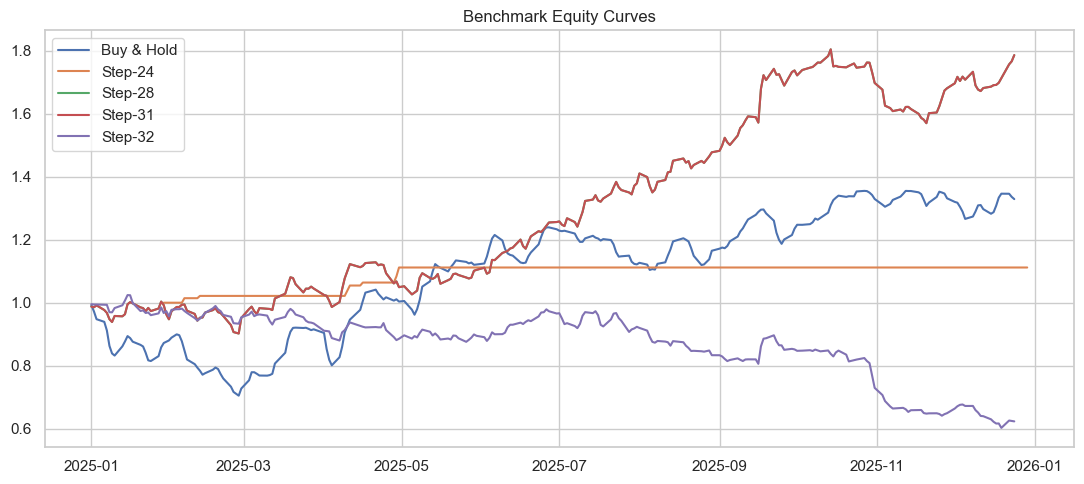

,Regime,Accuracy,Precision,Recall,F1,ROC_AUC
0,ALL,0.5082,0.5187,0.5568,0.5371,0.5115
1,LOW,0.5235,0.4944,0.4889,0.4916,0.5233
2,MEDIUM,0.4953,0.5000,0.5134,0.5066,0.4908
3,HIGH,0.5074,0.5414,0.6231,0.5794,0.5081


--- FINAL PROFESSIONAL SUMMARY ---
Best regime: HIGH
Best signal: Step-31 pred_final
Final IC: 0.0268
Final Sharpe: -2.1312
Final Drawdown: -0.4120
Final Trend Forecast Accuracy: 0.5082
Final Verdict: FAIL -> FALLBACK_STEP28_REGIME_FILTER
Saved:
  - c:\Users\Priyanshu\Desktop\Main\Financial-Marketing-Forecasting\ml_pipeline\Market_Data\final\step32_regime_aware_alpha_strategy.parquet
  - c:\Users\Priyanshu\Desktop\Main\Financial-Marketing-Forecasting\ml_pipeline\Market_Data\final\final_trend_forecasts.parquet
  - c:\Users\Priyanshu\Desktop\Main\Financial-Marketing-Forecasting\ml_pipeline\Market_Data\final\step32_metrics_summary.csv


In [6]:
# STEP 12 stress testing
stress_rows = []
for tx in [0.0010, 0.0015, 0.0030]:
    d = daily.copy()
    d['ret_stress'] = d['gross_return'] - (tx + SLIPPAGE) * d['turnover']
    mm = compute_metrics(d['ret_stress'])
    stress_rows.append({'Scenario': f'TX={tx:.2%}, SLIP={SLIPPAGE:.2%}', **mm})
for sl in [0.0005, 0.0010, 0.0020]:
    d = daily.copy()
    d['ret_stress'] = d['gross_return'] - (TX_COST + sl) * d['turnover']
    mm = compute_metrics(d['ret_stress'])
    stress_rows.append({'Scenario': f'TX={TX_COST:.2%}, SLIP={sl:.2%}', **mm})

# Regime exclusion tests
for reg_name, include_regs in [('MEDIUM_ONLY', {'MEDIUM'}), ('HIGH_ONLY', {'HIGH'})]:
    p = port[port['Regime'].isin(include_regs)].copy()
    d = p.groupby('Date', as_index=True)['net_component'].sum().sort_index()
    mm = compute_metrics(d)
    stress_rows.append({'Scenario': reg_name, **mm})

# Random signal benchmark
rng = np.random.default_rng(RANDOM_STATE)
rand_sharpes = []
for i in range(RANDOM_BENCHMARK_SIMS):
    rr = port[['Date', 'Ticker', 'target_future_return_t3', 'Regime', 'trade_allowed']].copy()
    rr['rand_score'] = rr.groupby('Date')['Ticker'].transform(lambda x: rng.permutation(np.arange(len(x))))
    rr['rand_rank'] = rr.groupby('Date')['rand_score'].rank(pct=True)
    rr['rand_side'] = np.where(rr['rand_rank'] >= 0.5, 1, -1)
    rr['rand_signal_strength'] = (rr['rand_rank'] - 0.5).abs()

    rows = []
    for dt, g in rr.groupby('Date', sort=True):
        c = g[g['trade_allowed']].copy()
        if len(c) < 2:
            continue
        longs = c[c['rand_side'] == 1].sort_values('rand_rank', ascending=False).head(TOP_N)
        shorts = c[c['rand_side'] == -1].sort_values('rand_rank', ascending=True).head(TOP_N)
        picks = pd.concat([longs, shorts], ignore_index=True)
        if len(picks) == 0:
            continue
        picks['w'] = picks['rand_side'] * (1.0 / TOP_N)
        picks['ret'] = picks['w'] * picks['target_future_return_t3']
        rows.append({'Date': dt, 'r': picks['ret'].sum()})
    if len(rows) == 0:
        continue
    dr = pd.DataFrame(rows).set_index('Date')['r'].sort_index()
    rand_sharpes.append(sharpe_ratio(dr))

rand_sharpe_mean = float(np.nanmean(rand_sharpes)) if len(rand_sharpes) else np.nan
stress_rows.append({'Scenario': 'Random signal benchmark (mean)', 'Total return': np.nan, 'CAGR': np.nan, 'Sharpe': rand_sharpe_mean, 'Sortino': np.nan, 'Max drawdown': np.nan, 'Volatility': np.nan, 'Calmar': np.nan, 'Win rate': np.nan})

stress_df = pd.DataFrame(stress_rows)
display(stress_df.round(4))

# STEP 13 benchmark comparison
step24_daily = step24[(step24['Date'] >= TEST_START) & (step24['Date'] <= TEST_END)].groupby('Date', as_index=True)['net_return'].sum().sort_index()
step28_daily = step28[['Date', 'daily_portfolio_return']].drop_duplicates('Date').set_index('Date')['daily_portfolio_return'].sort_index()
step31_daily = step31[['Date', 'daily_strategy_return']].drop_duplicates('Date').set_index('Date')['daily_strategy_return'].sort_index() if 'daily_strategy_return' in step31.columns else pd.Series(dtype=float)
bh_daily = base_df[(base_df['Date'] >= TEST_START) & (base_df['Date'] <= TEST_END)].groupby('Date', as_index=True)['target_future_return_t3'].mean().sort_index()

bench_rows = [
    {'Strategy': 'Buy & Hold', **compute_metrics(bh_daily)},
    {'Strategy': 'Step-24', **compute_metrics(step24_daily)},
    {'Strategy': 'Step-28', **compute_metrics(step28_daily)},
    {'Strategy': 'Step-31', **compute_metrics(step31_daily)},
    {'Strategy': 'Step-32', **m32},
]
bench_df = pd.DataFrame(bench_rows)
bench_df['Mean IC'] = np.nan
bench_df.loc[bench_df['Strategy'] == 'Step-28', 'Mean IC'] = float(step28['ic_mean_selected'].iloc[0]) if 'ic_mean_selected' in step28.columns else np.nan
bench_df.loc[bench_df['Strategy'] == 'Step-31', 'Mean IC'] = float(step31['ic_mean_step31'].dropna().iloc[0]) if 'ic_mean_step31' in step31.columns and step31['ic_mean_step31'].notna().any() else np.nan
bench_df.loc[bench_df['Strategy'] == 'Step-32', 'Mean IC'] = float(ic_day['IC'].mean()) if len(ic_day) else np.nan
bench_df['Monotonicity'] = np.nan
bench_df.loc[bench_df['Strategy'] == 'Step-32', 'Monotonicity'] = float(mono_spearman)
display(bench_df.round(4))

plt.figure(figsize=(11, 5))
plt.plot((1 + bh_daily).cumprod(), label='Buy & Hold')
plt.plot((1 + step24_daily).cumprod(), label='Step-24')
plt.plot((1 + step28_daily).cumprod(), label='Step-28')
if len(step31_daily):
    plt.plot((1 + step31_daily).cumprod(), label='Step-31')
plt.plot((1 + daily['net_return']).cumprod(), label='Step-32')
plt.title('Benchmark Equity Curves')
plt.legend()
plt.tight_layout()
plt.show()

# STEP 14 trend forecasting mapping
port['trend_prediction'] = (port['pred_rank_pct'] >= 0.5).astype(int)
port['confidence'] = (port['pred_rank_pct'] - 0.5).abs() * 2.0
port['trend_actual'] = (port['target_future_return_t3'] > 0).astype(int)
port['signal_label'] = np.where(
    (port['trend_prediction'] == 1) & (port['confidence'] >= 0.6), 'HIGH_CONFIDENCE_UP',
    np.where((port['trend_prediction'] == 0) & (port['confidence'] >= 0.6), 'HIGH_CONFIDENCE_DOWN', 'WEAK_SIGNAL')
)

# STEP 15 classification metrics overall + per regime
overall_cls = {
    'Accuracy': float(accuracy_score(port['trend_actual'], port['trend_prediction'])),
    'Precision': float(precision_score(port['trend_actual'], port['trend_prediction'], zero_division=0)),
    'Recall': float(recall_score(port['trend_actual'], port['trend_prediction'], zero_division=0)),
    'F1': float(f1_score(port['trend_actual'], port['trend_prediction'], zero_division=0)),
    'ROC_AUC': safe_roc_auc(port['trend_actual'], port['pred_rank_pct']),
}
cls_rows = [{'Regime': 'ALL', **overall_cls}]
for reg in ['LOW', 'MEDIUM', 'HIGH']:
    r = port[port['Regime'] == reg]
    if len(r) == 0:
        cls_rows.append({'Regime': reg, 'Accuracy': np.nan, 'Precision': np.nan, 'Recall': np.nan, 'F1': np.nan, 'ROC_AUC': np.nan})
        continue
    cls_rows.append({
        'Regime': reg,
        'Accuracy': float(accuracy_score(r['trend_actual'], r['trend_prediction'])),
        'Precision': float(precision_score(r['trend_actual'], r['trend_prediction'], zero_division=0)),
        'Recall': float(recall_score(r['trend_actual'], r['trend_prediction'], zero_division=0)),
        'F1': float(f1_score(r['trend_actual'], r['trend_prediction'], zero_division=0)),
        'ROC_AUC': safe_roc_auc(r['trend_actual'], r['pred_rank_pct']),
    })
cls_df = pd.DataFrame(cls_rows)
display(cls_df.round(4))

# STEP 17 final quality gate
step28_row = bench_df[bench_df['Strategy'] == 'Step-28'].iloc[0]
step32_row = bench_df[bench_df['Strategy'] == 'Step-32'].iloc[0]
mean_ic_32 = float(ic_day['IC'].mean()) if len(ic_day) else np.nan

quality_pass = bool(
    (step32_row['Sharpe'] > step28_row['Sharpe'])
    and (step32_row['Max drawdown'] >= step28_row['Max drawdown'])
    and (mean_ic_32 > 0)
    and (float(mono_spearman) > 0)
    and (step32_row['Sharpe'] > rand_sharpe_mean)
    and (overall_cls['Accuracy'] >= 0.52)
)

if not quality_pass:
    # Fallback to Step-28 + regime filter only.
    fallback = w.copy()
    fallback['pred_rank_pct'] = fallback.groupby('Date')['pred_anchor'].rank(pct=True)
    fallback['signal_strength'] = (fallback['pred_rank_pct'] - 0.5).abs()
    fallback['trade_allowed'] = fallback['Regime'].isin(['MEDIUM', 'HIGH'])
    fallback['trade_candidate'] = fallback['trade_allowed']
    fallback['side'] = np.where(fallback['pred_rank_pct'] >= 0.5, 1, -1)

    fr_rows = []
    for dt, g in fallback.groupby('Date', sort=True):
        c = g[g['trade_candidate']].copy()
        longs = c[c['side'] == 1].sort_values('pred_rank_pct', ascending=False).head(TOP_N)
        shorts = c[c['side'] == -1].sort_values('pred_rank_pct', ascending=True).head(TOP_N)
        picks = pd.concat([longs, shorts], ignore_index=True)
        if len(picks) == 0:
            g2 = g.copy(); g2['weight_pre'] = 0.0; fr_rows.append(g2); continue
        picks['weight_pre'] = picks['side'] * (1.0 / TOP_N)
        g2 = g.copy().merge(picks[['Ticker', 'weight_pre']], on='Ticker', how='left')
        g2['weight_pre'] = g2['weight_pre'].fillna(0.0)
        fr_rows.append(g2)
    port = pd.concat(fr_rows, ignore_index=True).sort_values(['Ticker', 'Date']).reset_index(drop=True)
    port['prev_weight'] = port.groupby('Ticker', sort=False)['weight_pre'].shift(1).fillna(0.0)
    port['turnover_component'] = (port['weight_pre'] - port['prev_weight']).abs()
    port['gross_component'] = port['weight_pre'] * port['target_future_return_t3']
    port['cost_component'] = (TX_COST + SLIPPAGE) * port['turnover_component']
    port['net_component'] = port['gross_component'] - port['cost_component']
    daily = port.groupby('Date', as_index=True)['net_component'].sum().to_frame('net_return')
    port['daily_strategy_return'] = port['Date'].map(daily['net_return'])
    port['pred_final'] = port['pred_anchor']
    port['pred_zscore'] = port.groupby('Date')['pred_final'].transform(cs_zscore)
    port['pred_rank_pct'] = port.groupby('Date')['pred_final'].rank(pct=True)
    port['signal_label'] = np.where((port['pred_rank_pct'] >= 0.5) & ((port['pred_rank_pct'] - 0.5).abs() * 2 >= 0.6), 'HIGH_CONFIDENCE_UP', np.where((port['pred_rank_pct'] < 0.5) & ((port['pred_rank_pct'] - 0.5).abs() * 2 >= 0.6), 'HIGH_CONFIDENCE_DOWN', 'WEAK_SIGNAL'))
    final_verdict = 'FAIL -> FALLBACK_STEP28_REGIME_FILTER'
else:
    port['daily_strategy_return'] = port['Date'].map(daily['net_return'])
    final_verdict = 'PASS'

# STEP 16 save outputs
strategy_cols = [
    'Date', 'Ticker', 'Regime',
    'target_future_return_t3', 'pred_anchor', 'signal_raw', 'pred_rank_pct', 'pred_zscore',
    'signal_strength', 'trade_allowed', 'tail_selected', 'trade_candidate',
    'side', 'weight_pre', 'turnover_component', 'gross_component', 'cost_component', 'net_component',
    'daily_strategy_return', 'trend_prediction', 'confidence', 'signal_label'
]
for c in ['trend_prediction', 'confidence', 'signal_label']:
    if c not in port.columns:
        port[c] = np.nan
strategy_cols = [c for c in strategy_cols if c in port.columns]

trend_cols = [
    'Date', 'Ticker', 'Regime',
    'pred_rank_pct', 'pred_zscore', 'trend_prediction', 'trend_actual', 'confidence', 'signal_label', 'daily_strategy_return'
]
trend_cols = [c for c in trend_cols if c in port.columns]

metrics_summary = pd.DataFrame([
    {'Metric': 'Step32_Mean_IC', 'Value': mean_ic_32},
    {'Metric': 'Step32_Sharpe', 'Value': step32_row['Sharpe']},
    {'Metric': 'Step32_MaxDrawdown', 'Value': step32_row['Max drawdown']},
    {'Metric': 'Step32_Monotonicity', 'Value': float(mono_spearman)},
    {'Metric': 'Step32_Trend_Accuracy', 'Value': overall_cls['Accuracy']},
    {'Metric': 'Step32_Trend_Precision', 'Value': overall_cls['Precision']},
    {'Metric': 'Step32_Trend_Recall', 'Value': overall_cls['Recall']},
    {'Metric': 'Step32_Trend_F1', 'Value': overall_cls['F1']},
    {'Metric': 'Step32_Trend_ROCAUC', 'Value': overall_cls['ROC_AUC']},
    {'Metric': 'Random_Benchmark_Sharpe', 'Value': rand_sharpe_mean},
    {'Metric': 'Final_Verdict', 'Value': final_verdict},
])

OUT_STRATEGY.parent.mkdir(parents=True, exist_ok=True)
port[strategy_cols].to_parquet(OUT_STRATEGY, index=False)
port[trend_cols].to_parquet(OUT_TREND, index=False)
metrics_summary.to_csv(OUT_METRICS, index=False)

# Final professional summary
best_reg = regime_diag.sort_values('Mean_IC', ascending=False).iloc[0]['Regime']
best_sig = selected_signal

print('--- FINAL PROFESSIONAL SUMMARY ---')
print(f'Best regime: {best_reg}')
print(f'Best signal: {best_sig}')
print(f"Final IC: {mean_ic_32:.4f}")
print(f"Final Sharpe: {step32_row['Sharpe']:.4f}")
print(f"Final Drawdown: {step32_row['Max drawdown']:.4f}")
print(f"Final Trend Forecast Accuracy: {overall_cls['Accuracy']:.4f}")
print(f'Final Verdict: {final_verdict}')
print('Saved:')
print(f'  - {OUT_STRATEGY}')
print(f'  - {OUT_TREND}')
print(f'  - {OUT_METRICS}')
